## **1. Import Libraries**
---

In [1]:
# Download ICDAR 2003 dataset (~45MB)
# https://drive.google.com/file/d/1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV/view
!gdown 1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
!unzip -q icdar2003.zip -d datasets

Downloading...
From (original): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
From (redirected): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV&confirm=t&uuid=cbab766c-8107-4db2-9392-420d91ffc3d7
To: /kaggle/working/icdar2003.zip
100%|███████████████████████████████████████| 45.7M/45.7M [00:00<00:00, 224MB/s]


In [2]:
%pip install -q -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.3/949.3 kB 16.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import yaml
import json
import shutil
import requests
import numpy as np
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split

import cv2
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics 8.3.92 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6170.0/8062.4 GB disk)


In [4]:
# # Fast check if the model is working
# !yolo predict model=yolo11m.pt source='https://ultralytics.com/images/bus.jpg'

## **2. Extract Data from XML and Store in YOLO format**
---

In [5]:
def extract_data_from_xml(path):
    tree = ET.parse(path)
    root = tree.getroot()

    image_paths, image_sizes, image_labels, bounding_boxes = [], [], [], []
    for image in root:
        bbs_of_image, labels_of_image = [], []

        for bbs in image.findall("taggedRectangles"):
            for bb in bbs:
                
                # Check non-alphabet and non-number
                if not bb[0].text.isalnum():
                    continue
                if "é" in bb[0].text.lower() or "ñ" in bb[0].text.lower():
                    continue

                # Save coordinate
                bbs_of_image.append([
                    float(bb.attrib["x"]),
                    float(bb.attrib["y"]),
                    float(bb.attrib["width"]),
                    float(bb.attrib["height"]),
                ])
                labels_of_image.append(bb[0].text.lower())

        # Store
        image_paths.append(image[0].text)
        image_sizes.append((int(image[1].attrib["x"]), int(image[1].attrib["y"])))
        image_labels.append(labels_of_image)
        bounding_boxes.append(bbs_of_image)

    return image_paths, image_sizes, image_labels, bounding_boxes

In [6]:
dataset_dir = "datasets/SceneTrialTrain"

image_paths, image_sizes, image_labels, bounding_boxes = extract_data_from_xml(os.path.join(dataset_dir, "words.xml"))

In [7]:
print(f"Number of images      : {len(image_paths)}")
print(f"Example image path    : {image_paths[0]}")
print(f"Example image size    : {image_sizes[0]}")
print(f"Example bounding boxes: {bounding_boxes[0][:2]}")
print(f"Example labels        : {image_labels[0][:2]}")

Number of images      : 250
Example image path    : apanar_06.08.2002/IMG_1261.JPG
Example image size    : (1600, 1200)
Example bounding boxes: [[174.0, 392.0, 274.0, 195.0], [512.0, 391.0, 679.0, 183.0]]
Example labels        : ['self', 'adhesive']


## **3. Convert Data to YOLO format**
---

In [8]:
def convert_to_yolo_format(image_paths, image_sizes, bounding_boxes):
    yolo_data = []

    for image_path, image_size, bboxes in zip(image_paths, image_sizes, bounding_boxes):
        image_width, image_height = image_size

        yolo_labels = []
        for bbox in bboxes:
            x, y, w, h = bbox

            # Calculate normalized bounding box coordinates
            center_x          = (x + w / 2) / image_width
            center_y          = (y + h / 2) / image_height
            normalized_width  = w / image_width
            normalized_height = h / image_height

            # Only have one class -> set class_id to 0
            class_id = 0

            # Convert to YOLO format
            yolo_label = f"{class_id} {center_x} {center_y} {normalized_width} {normalized_height}"
            yolo_labels.append(yolo_label)
        yolo_data.append((image_path, yolo_labels))
        
    return yolo_data

In [9]:
yolo_data = convert_to_yolo_format(image_paths, image_sizes, bounding_boxes)

## **4. Train/Val/Test split & Save Data**
---

In [10]:
def save_data(data, src_img_dir, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, "images"), exist_ok=True)
    os.makedirs(os.path.join(save_dir, "labels"), exist_ok=True)

    for image_path, yolo_labels in data:
        # Copy image to images folder
        shutil.copy(os.path.join(src_img_dir, image_path), os.path.join(save_dir, "images"))

        # Save labels to labels folder
        image_name = os.path.basename(image_path)
        image_name = os.path.splitext(image_name)[0]

        with open(os.path.join(save_dir, "labels", f"{image_name}.txt"), "w") as f:
            for label in yolo_labels:
                f.write(f"{label}\n")

In [11]:
train_data, test_data = train_test_split(yolo_data, test_size=0.2  , random_state=0, shuffle=True)
test_data , val_data  = train_test_split(test_data, test_size=0.125, random_state=0, shuffle=True)

In [12]:
save_yolo_data_dir = "datasets/yolo_data"
os.makedirs(save_yolo_data_dir, exist_ok=True)

save_train_dir = os.path.join(save_yolo_data_dir, "train")
save_val_dir   = os.path.join(save_yolo_data_dir, "val")
save_test_dir  = os.path.join(save_yolo_data_dir, "test")

save_data(train_data, dataset_dir, save_train_dir)
save_data(test_data , dataset_dir, save_val_dir)
save_data(val_data  , dataset_dir, save_test_dir)

## **5. Training & Evaluation**
---

In [13]:
# Create .yaml file
class_labels = ["text"]

data_yaml = {
    "train": "train/images",
    "test" : "test/images",
    "val"  : "val/images",
    "nc"   : 1,
    "names": class_labels,
}

yolo_yaml_path = os.path.join(save_yolo_data_dir, "data.yml")
with open(yolo_yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

In [14]:
# Load YOLOv11 model
model = YOLO("yolo11m.pt")

# Train model
results = model.train(
    data=os.path.join(os.getcwd(), yolo_yaml_path),
    epochs=100,
    imgsz=640,
    cache=True,
    patience=20,
    plots=True,
)

100%|██████████| 38.8M/38.8M [00:00<00:00, 227MB/s]


Ultralytics 8.3.92 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11m.pt, data=/kaggle/working/datasets/yolo_data/data.yml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=

100%|██████████| 755k/755k [00:00<00:00, 17.6MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 76.7MB/s]


...


100 epochs completed in 0.241 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 40.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 40.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.92 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.99it/s]


                   all         43        200      0.881      0.905      0.925      0.722


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 10.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/train


In [15]:
model_path = "./runs/detect/train/weights/best.pt"
model      = YOLO(model_path)
metrics    = model.val()

Ultralytics 8.3.92 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


val: Scanning /kaggle/working/datasets/yolo_data/val/labels.cache... 43 images, 2 backgrounds, 0 corrupt: 100%|██████████| 43/43 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.88it/s]


                   all         43        200      0.881      0.905      0.925      0.718


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 3.3ms preprocess, 22.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/val


## **6. Inference**
---

In [16]:
def visualize_bbox(img, predictions, conf_thres=0.8, font=cv2.FONT_HERSHEY_SIMPLEX):
    h, w = img.shape[:2]

    for prediction in predictions:
        conf_score = prediction["confidence"]
        if conf_score < conf_thres:
            continue

        bbox       = prediction["box"]
        xmin, ymin = int(bbox["x1"]), int(bbox["y1"])
        xmax, ymax = int(bbox["x2"]), int(bbox["y2"])

        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

        text = f"{conf_score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(text, font, 1, 2)

        cv2.rectangle(img, (xmin, ymin - text_height - 5), (xmin + text_width, ymin), (0, 255, 0), -1)
        cv2.putText(img, text, (xmin, ymin - 5), font, 1, (0, 0, 0), 2)

    return img

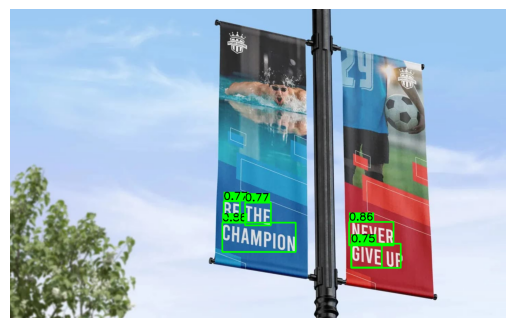

In [17]:
url      = "https://wttb.co.uk/_next/image?url=https%3A%2F%2Fimages.ctfassets.net%2Fd3bnr0l99nhx%2F1TBRdrXUxinF5HOWrl75fw%2F2937e6cc09c4e8ff0ba001f7d25ea89f%2Flamp-post-banner-1.webp&w=3840&q=75"
response = requests.get(url)
img_pil  = Image.open(BytesIO(response.content))

img_cv2 = np.array(img_pil)
img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_RGB2BGR)

model_path = "./runs/detect/train/weights/best.pt"
model      = YOLO(model_path)
conf_thres = 0.7

# Inference
results        = model(img_pil, verbose=False)
predictions    = json.loads(results[0].to_json())

# Visualize
visualized_img     = visualize_bbox(img_cv2, predictions, conf_thres)
visualized_img_rgb = cv2.cvtColor(visualized_img, cv2.COLOR_BGR2RGB)

plt.imshow(visualized_img_rgb)
plt.axis("off")
plt.show()